In [7]:
                                          # Binomial Logistic Regression
# Steps 1 : Genrative datasets 
# Step 2 : sigmoid and cost function 
# step 3 : gradient descent ko dekhna 
# step 4 : 3d visualization

In [8]:
# Genrative datasets
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
np.random.seed(42)

In [9]:
# class 0 
x0=np.random.normal(2,1,50)
y0=np.random.normal(2,1,50)

In [10]:
# class 1
x1=np.random.normal(5,1,50)
y1=np.random.normal(5,1,50)


# X and Y value 

X = np.vstack((np.hstack((x0,x1)),np.hstack((y0,y1)))).T

Y=np.hstack((np.zeros(50),np.ones(50)))


In [11]:
# Bias addition 
X_bias=np.hstack((np.ones((X.shape[0],1)),X))

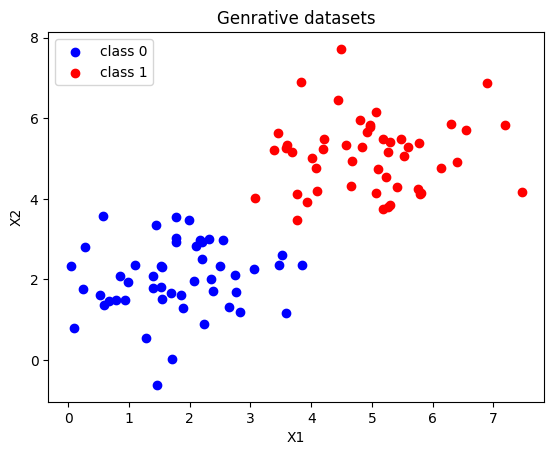

In [12]:
# Scatter to check datasets
plt.scatter(x0,y0,color="blue",label="class 0")
plt.scatter(x1,y1,color="red",label="class 1")
plt.legend()
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Genrative datasets")
plt.show()

In [13]:
# sigmoid function
def sigmoid(z):
    return 1/1+np.exp(-z)

# cost function
def costfun(theta,X,Y):
    m=len(Y)
    h=sigmoid(X@theta)
    epsion=1e-5
    return -1/m*np.sum(Y*np.log(h+epsion)+(1-Y)*np.log(1-h+epsion))

In [14]:
# gradient descent 
def gradient_descent(X, Y, lr=0.1, iterations=50):
    theta = np.zeros(X.shape[1])
    cost_history = []
    theta_history = []

    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/len(Y)) * (X.T @ (h - Y))
        theta -= lr * gradient

        cost_history.append(costfun(theta, X, Y))
        theta_history.append(theta.copy())

    return theta, cost_history, np.array(theta_history)

# Run Gradient Descent
theta_opt, cost_hist, theta_hist = gradient_descent(X_bias, Y)
print("Optimal Thetas:", theta_opt)

Optimal Thetas: [nan nan nan]


C:\Users\priya\AppData\Local\Temp\ipykernel_13424\3761257358.py:10: RuntimeWarning: invalid value encountered in log
  return -1/m*np.sum(Y*np.log(h+epsion)+(1-Y)*np.log(1-h+epsion))
C:\Users\priya\AppData\Local\Temp\ipykernel_13424\3761257358.py:3: RuntimeWarning: overflow encountered in exp
  return 1/1+np.exp(-z)
C:\Users\priya\AppData\Local\Temp\ipykernel_13424\3761257358.py:10: RuntimeWarning: invalid value encountered in multiply
  return -1/m*np.sum(Y*np.log(h+epsion)+(1-Y)*np.log(1-h+epsion))
C:\Users\priya\AppData\Local\Temp\ipykernel_13424\3962164175.py:9: RuntimeWarning: invalid value encountered in matmul
  gradient = (1/len(Y)) * (X.T @ (h - Y))


C:\Users\priya\AppData\Local\Temp\ipykernel_13424\3761257358.py:10: RuntimeWarning: invalid value encountered in log
  return -1/m*np.sum(Y*np.log(h+epsion)+(1-Y)*np.log(1-h+epsion))
c:\python3.11\New folder\Lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:148: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)


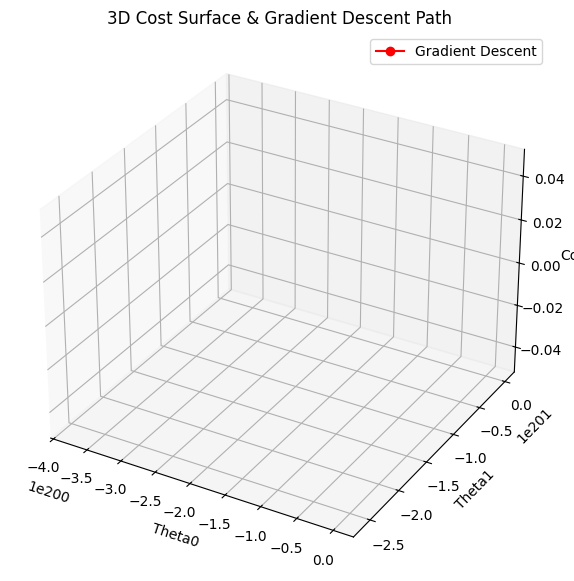

In [15]:
# Visualization in 3D
# 3D Cost Surface
theta0_vals = np.linspace(-1, 6, 50)
theta1_vals = np.linspace(-1, 6, 50)
Theta0, Theta1 = np.meshgrid(theta0_vals, theta1_vals)
Cost_surface = np.zeros_like(Theta0)

# Fix theta2=0
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([Theta0[i,j], Theta1[i,j], 0])
        Cost_surface[i,j] = costfun(t, X_bias, Y)

# Plotting
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Theta0, Theta1, Cost_surface, alpha=0.6, cmap='viridis')
ax.plot(theta_hist[:,0], theta_hist[:,1], cost_hist, color='r', marker='o', label='Gradient Descent')
ax.set_xlabel('Theta0')
ax.set_ylabel('Theta1')
ax.set_zlabel('Cost')
ax.set_title('3D Cost Surface & Gradient Descent Path')
ax.legend()
plt.show()